In [1]:
import pandas as pd

df = pd.read_csv("claims_dataset.csv")

print(df.head())
print(df['label'].value_counts())


                                                text  label
0  We reduced Scope 1 and Scope 2 emissions by 33...      1
1  The company committed to achieving net zero em...      1
2  In 2023/24, 70% of polyester used in Clothing ...      1
3  We removed 144 million pieces of plastic from ...      1
4  Food waste was reduced by 44% against the base...      1
label
0    526
1    306
Name: count, dtype: int64


In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""

In [3]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df["label"],
    random_state=42
)


In [4]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )


d:\ESG_platform\esg_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
from datasets import Dataset

train_ds = Dataset.from_pandas(train_df)
val_ds   = Dataset.from_pandas(val_df)

train_ds = train_ds.map(tokenize, batched=True)
val_ds   = val_ds.map(tokenize, batched=True)

train_ds = train_ds.remove_columns(["text"])
val_ds   = val_ds.remove_columns(["text"])

train_ds = train_ds.rename_column("label", "labels")
val_ds   = val_ds.rename_column("label", "labels")

train_ds.set_format("torch")
val_ds.set_format("torch")


Map: 100%|██████████| 125/125 [00:00<00:00, 3286.10 examples/s]


In [6]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [7]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./claim_classifier",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="f1"
)


In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    # Predicted class
    preds = logits.argmax(axis=-1)

    # Convert logits → probabilities (softmax)
    probs = np.exp(logits) / np.exp(logits).sum(axis=-1, keepdims=True)

    # Probability of positive class (class = 1)
    pos_probs = probs[:, 1]

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )
    acc = accuracy_score(labels, preds)

    # ROC-AUC
    try:
        roc_auc = roc_auc_score(labels, pos_probs)
    except:
        roc_auc = 0.0  # fallback if only one class present

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc
    }

In [9]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_22476\1482414042.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
d:\ESG_platform\esg_venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,No log,0.159608,0.936000,0.880000,0.956522,0.916667,0.995322
2,No log,0.098349,0.952000,0.934783,0.934783,0.934783,0.995872


d:\ESG_platform\esg_venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=90, training_loss=0.23580171797010635, metrics={'train_runtime': 491.4015, 'train_samples_per_second': 2.877, 'train_steps_per_second': 0.183, 'total_flos': 93009758069760.0, 'train_loss': 0.23580171797010635, 'epoch': 2.0})

In [11]:
pred_output = trainer.predict(val_ds)

logits = pred_output.predictions
labels = pred_output.label_ids

# Convert to predictions
preds = np.argmax(logits, axis=1)

# Softmax → probabilities
probs = np.exp(logits) / np.exp(logits).sum(axis=-1, keepdims=True)
pos_probs = probs[:, 1]

d:\ESG_platform\esg_venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


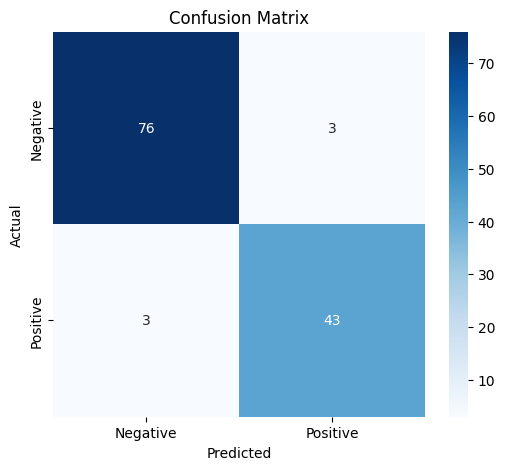

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

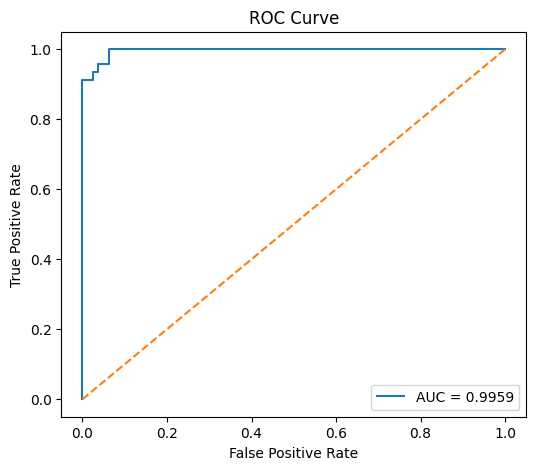

In [13]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(labels, pos_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [18]:
import torch
import torch.nn.functional as F

def predict(text):
    model.eval()
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    )
    with torch.no_grad():
        outputs = model(**inputs)
        probs = F.softmax(outputs.logits, dim=-1)
        pred = probs.argmax(dim=-1).item()
    return pred, probs.tolist()

predict("100% of our operations are in scope of our Operational Excellence Management System (OEMS), which is third-party reviewed for alignment with the intent of the RC14001® standa")


(1, [[0.46735551953315735, 0.532644510269165]])

In [19]:
SAVE_DIR = "../bert_claim_classifier"

model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)


('../bert_claim_classifier\\tokenizer_config.json',
 '../bert_claim_classifier\\special_tokens_map.json',
 '../bert_claim_classifier\\vocab.txt',
 '../bert_claim_classifier\\added_tokens.json')

ModuleNotFoundError: No module named 'pandas'